# DCAFA: Differential Community Abundance and Feature Analysis for Histological Images

In [1]:
import DCAFA
import pandas as pd
import numpy as np

---

**Motivation.** Many biomedical, imaging, and omics datasets are **hierarchical**: fine-grained **instances** (e.g., cells, image patches, spots) live inside **bags** (e.g., patients, slides, samples). Instances can be grouped into **communities** with **hard** or **soft** memberships $m_{pk}\in[0,1]$. When bag-level outcomes $y_i$ and/or instance-level outcomes $t_p$ exist, we need tools that (i) quantify **differential community abundance** across outcomes and (ii) attribute **which features** explain differences **at both bag and instance levels**.

**Setup.** Bags $i=1,\dots,N$; instances $p=1,\dots,P$ with bag map $s(p)=i$; instance features $x_p\in\mathbb{R}^d$; memberships $m_{pk}\in[0,1]$ for communities $k=1,\dots,K$. Bag size
$$
n_i \;=\; \sum_{p:\,s(p)=i} 1,
$$
community “counts” per bag
$$
c_{ik} \;=\; \sum_{p:\,s(p)=i} m_{pk}.
$$
Outcomes may be bag-level $y_i\in\mathbb{R}^{R_y}$ or instance-level $t_p\in\mathbb{R}^{R_t}$. Optional bag covariates $v_i\in\mathbb{R}^q$.

---

## Feature Analysis (FA)

### FA for Instance-level targets

**Goal.**  
Discover which original instance features explain variation in instance outcomes.

**Core idea.**  
If we regress instance-level outcomes directly on instance features, significant coefficients reveal which features are predictive of outcomes.

**Model (per component $r$).**
$$
t_{p,r} \;\sim\; x_p + v_{s(p)} + (1\,|\,s(p)),
$$

with link $g_r(\cdot)$:
$$
g_r\!\big(\mathbb{E}[t_{p,r}]\big)
\;=\;
\alpha_{0r}
\;+\;
x_p^\top \alpha_r
\;+\;
v_{s(p)}^\top \eta_r
\;+\;
u_{s(p),r}.
$$

This allows modelling different types (continuous (gaussian), binary (binomial), count (poisson)) targets.

**Reporting and interpretation.**  
- Effect size: $\widehat{\alpha}_{r,j}$ = change in outcome per unit of feature $j$.  
- Report $\exp(\widehat{\alpha}_{r,j})$ as odds/rate ratios for non-Gaussian links.  
- Hypothesis: $H_0:\alpha_{r,j}=0$.  
- Intuition: large, significant $\widehat{\alpha}_{r,j}$ values highlight features predictive of $t_{p,r}$.

**Caveats.**  
- High-dimensional $x_p$: risk of multicollinearity → use penalized GLMs or dimension reduction.  
- Always use bag-clustered SEs or random effects.  

**Interpretation** 

*Which instance features explain outcomes?*  

---

In [19]:
# Toy dataset with 5 features and one feature differential by target
data = np.random.rand(100, 5)
difference = np.random.rand(50, 1) * 1.5 + 2  
difference = np.concatenate([difference, np.zeros((50, 1))], axis=0)
data[:, 0] += difference.flatten()

# Combine data and target into a DataFrame for input to DCAFA
df = pd.DataFrame(data, columns=[f'x_{i+1}' for i in range(5)])

# Create the target variables
df['target'] = np.concatenate([np.random.rand(50) * 0.5 + 0.5, np.random.rand(50) * 0.5])
df['inverse_target'] = 1 - df['target']
df['PID'] = range(1, 101)  # Add a PID column

df

,x_1,x_2,x_3,x_4,x_5,target,inverse_target,PID
0,3.658985,0.931022,0.280293,0.893139,0.919282,0.886193,0.113807,1
1,2.879235,0.643646,0.768131,0.816765,0.559911,0.608414,0.391586,2
2,2.445967,0.427278,0.191036,0.375330,0.488332,0.513407,0.486593,3
3,2.495721,0.073827,0.527258,0.430627,0.271303,0.987610,0.012390,4
4,3.741009,0.026241,0.241042,0.840504,0.697796,0.886736,0.113264,5
...,...,...,...,...,...,...,...,...
95,0.280360,0.738583,0.143561,0.783848,0.667495,0.448947,0.551053,96
96,0.853963,0.730244,0.731352,0.414048,0.863445,0.256626,0.743374,97
97,0.273660,0.401494,0.049513,0.894899,0.107118,0.329808,0.670192,98
98,0.922437,0.848265,0.406751,0.859133,0.604458,0.121891,0.878109,99


In [20]:
# ---- Fit FA UNIVARIATE GLMs for both targets ----
feature_cols = [f"x_{i+1}" for i in range(5)]
target_cols = ["target", 'inverse_target'] 

covariates = []  # optional; can be [] if none

results = DCAFA.fit_inst_fa(
    df=df.copy(),
    feature_cols=feature_cols,
    target_cols=target_cols,
    covariates=covariates,
    bag_id_col="PID",
    families={tgt: "gaussian" for tgt in target_cols},
    cov_type="cluster"
)

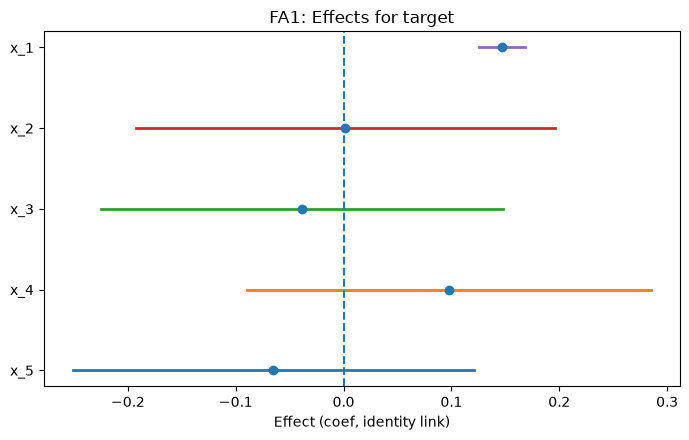

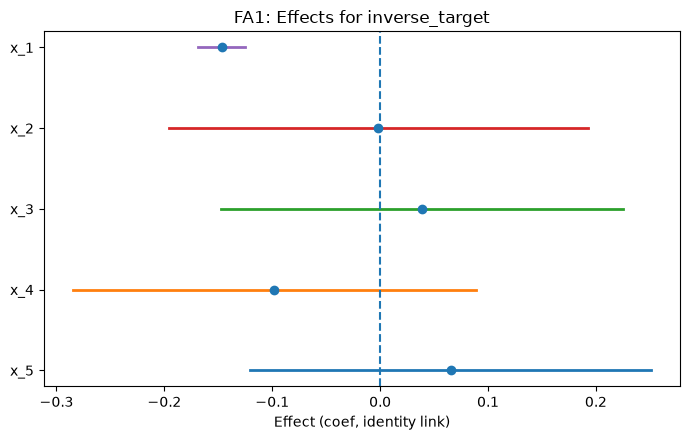

In [21]:
# ---- Plot forest plots per target ----
for tgt, eff_df in results.items():
    DCAFA.plot_fa_inst_forest(
        effects_df=eff_df,
        title=f"FA1: Effects for {tgt}",
        only_features=True
    )

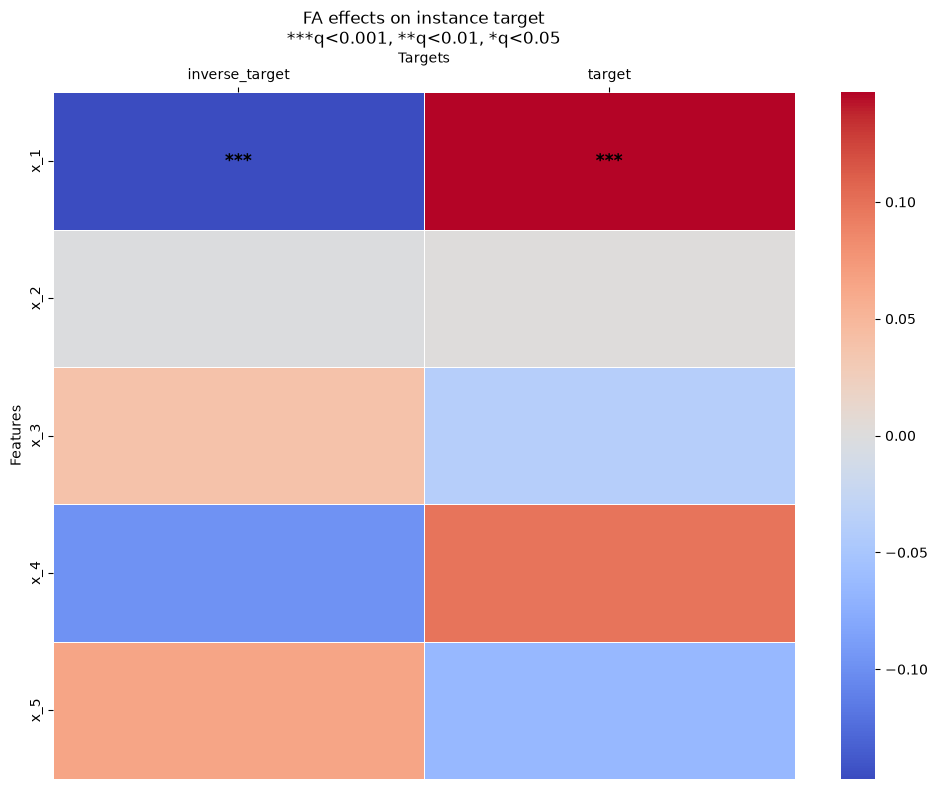

In [23]:
# ---- Plot heatmap of effects ----
DCAFA.plot_fa_inst_heatmap(results)

### FA for Bag-level targets


**Goal.**  
Identify which aggregated instance features predict bag-level outcomes.

**Core idea.**  
If we regress bag-level outcomes on aggregate statistics of instance features (global averages or community-specific averages), significant coefficients highlight predictive features at the bag level.

**Models.**

1. **Broadcast supervision (weak supervision).**
$$
t_{p,m} := y_{s(p),m}, \qquad
t_{p,m} \;\sim\; x_p + v_{s(p)} + (1\,|\,s(p)).
$$

2. **Global mean aggregation.**
$$
\tilde{x}_i \;=\; \tfrac{1}{n_i}\sum_{p:\,s(p)=i} x_p, \qquad
y_{i,m} \;\sim\; \tilde{x}_i + v_i.
$$

3. **Community mean aggregation.**
$$
\bar{x}_{ik} \;=\; \tfrac{1}{c_{ik}}\sum_{p:\,s(p)=i} m_{pk}\,x_p, \qquad
y_{i,m} \;\sim\; \sum_{k=1}^K \bar{x}_{ik} + v_i.
$$

**Reporting and interpretation.**  
- Effect size: $\widehat{\zeta}_{m,j}$ (global) or $\widehat{\psi}_{k,m,j}$ (community-specific).  
- Report $\exp(\cdot)$ for odds/rate ratios.  
- Hypothesis: $H_0:\zeta_{m,j}=0$ or $H_0:\psi_{k,m,j}=0$.  
- Intuition: identifies which features (globally or within communities) explain bag-level outcomes.

**Caveats.**  
- If $c_{ik}=0$, $\bar{x}_{ik}$ undefined → handle with dropping/imputation.  
- Aggregation may obscure signals if only subsets of instances are predictive.  
- Multiple testing correction required across features and communities.

**Interpretation** 
- Global mean aggregation - *Do bag-level averages of features predict outcomes?* 
- Community mean aggregation - *Do aggregated features within annotated groups predict outcomes?* 

---

In [36]:
# Our example only shows global mean aggregation (broadcast supervision you can use instance level DCAFA with target as the bag label with bag label as a covariate)
n_instances = 1000
instances_per_bag = 20
n_bags = n_instances // instances_per_bag

# Base data
data = np.random.rand(n_instances, 5)

# Assign bags
bag_ids = np.repeat(np.arange(n_bags), instances_per_bag)

# Choose which bags have signal
signal_bags = np.random.choice(n_bags, size=n_bags // 2, replace=False)

# Inject signal ONLY into those bags
for b in signal_bags:
    idx = (bag_ids == b)
    data[idx, 0] += np.random.rand() * 2 + 2  # strong shift

# Build df
df = pd.DataFrame(data, columns=[f'x_{i+1}' for i in range(5)])
df['PID'] = [f'PID_{i}' for i in bag_ids]

# Targets correlated with signal
bag_targets = np.zeros(n_bags)
bag_targets[signal_bags] = np.random.rand(len(signal_bags)) * 0.5 + 0.5  # higher target for signal bags

df['target'] = np.repeat(bag_targets, instances_per_bag)
df['inverse_target'] = 1 - df['target']

df

,x_1,x_2,x_3,x_4,x_5,PID,target,inverse_target
0,0.680673,0.320013,0.760304,0.759602,0.148936,PID_0,0.000000,1.000000
1,0.677049,0.635639,0.397988,0.425444,0.785841,PID_0,0.000000,1.000000
2,0.469673,0.200195,0.347812,0.886502,0.364443,PID_0,0.000000,1.000000
3,0.647962,0.656667,0.006344,0.814102,0.592238,PID_0,0.000000,1.000000
4,0.078101,0.424880,0.270178,0.335771,0.974017,PID_0,0.000000,1.000000
...,...,...,...,...,...,...,...,...
995,3.123994,0.996409,0.859442,0.446459,0.494542,PID_49,0.671424,0.328576
996,3.041395,0.223124,0.045489,0.199913,0.243264,PID_49,0.671424,0.328576
997,2.848268,0.577098,0.619078,0.807212,0.982231,PID_49,0.671424,0.328576
998,2.496261,0.473292,0.146696,0.779051,0.411482,PID_49,0.671424,0.328576


In [37]:
# first we need to aggregate the features for the bags

feature_cols = [f"x_{i+1}" for i in range(5)]  # x_1, ..., x_5

df_bag_design = DCAFA.aggregate_bag_features(
    df_instances=df,
    feature_cols=feature_cols,
    membership_cols=None,
    bag_id_col="PID",
    min_count_for_mean=1
)

df_bag_design.head()

,PID,n,xg_x_1,xg_x_2,xg_x_3,xg_x_4,xg_x_5
0,PID_0,20,0.528710,0.509498,0.513432,0.531756,0.586223
1,PID_1,20,0.398996,0.512081,0.571187,0.549230,0.565737
2,PID_10,20,0.487867,0.461955,0.556958,0.573032,0.433555
3,PID_11,20,2.981764,0.466156,0.506383,0.486296,0.564828
4,PID_12,20,0.465137,0.553646,0.422455,0.557301,0.547684


In [38]:
# ---- Fit FA UNIVARIATE GLMs for both targets on the aggregated bag-level data ----

target_cols = ["target", 'inverse_target'] 

family_by_target = {t: "gaussian" for t in target_cols}

df_bags_targets_covs = df[['PID'] + target_cols].drop_duplicates()

agg_results = DCAFA.fit_fa_aggregate(
    df_bag_design=df_bag_design,
    df_bags_targets_covs=df_bags_targets_covs,
    target_cols=target_cols,
    covariate_cols=[],
    use_global_means=True,
    use_community_means=False,
    family_by_target=family_by_target,
    bag_id_col="PID",
    cov_type="HC1"
)


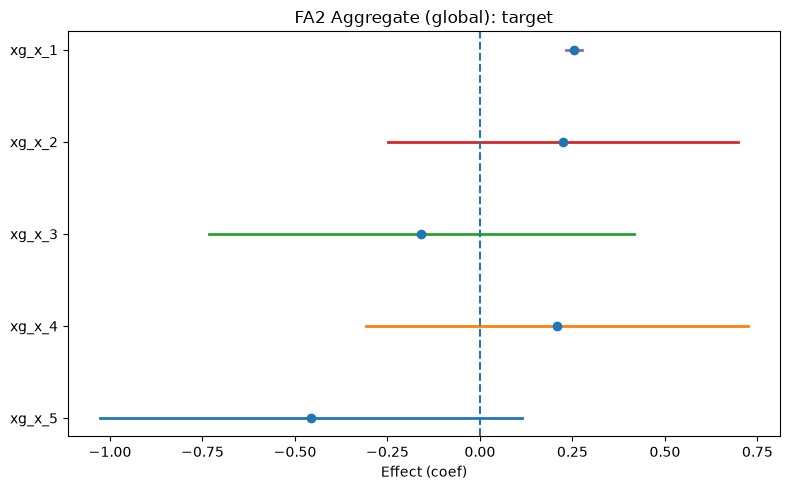

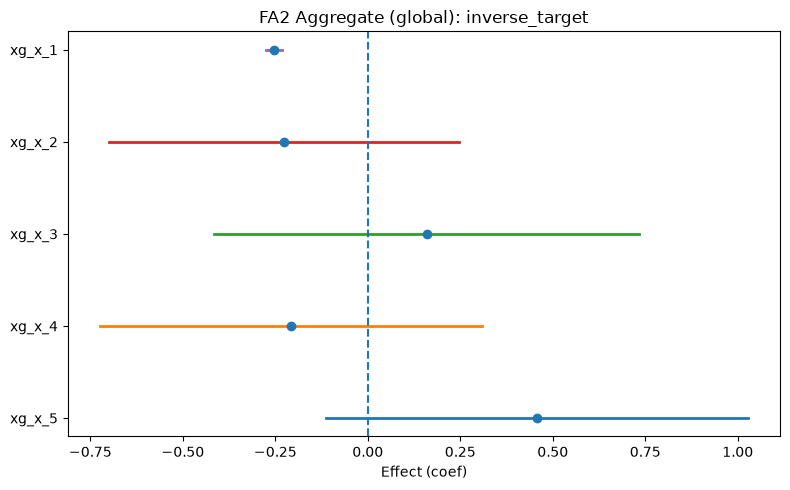

In [39]:
# ---- Plot forest plots per target ----
for tgt, eff_df in agg_results.items():
    DCAFA.plot_fa_aggregate_forest(eff_df, title=f"FA2 Aggregate (global): {tgt}", highlight="global")

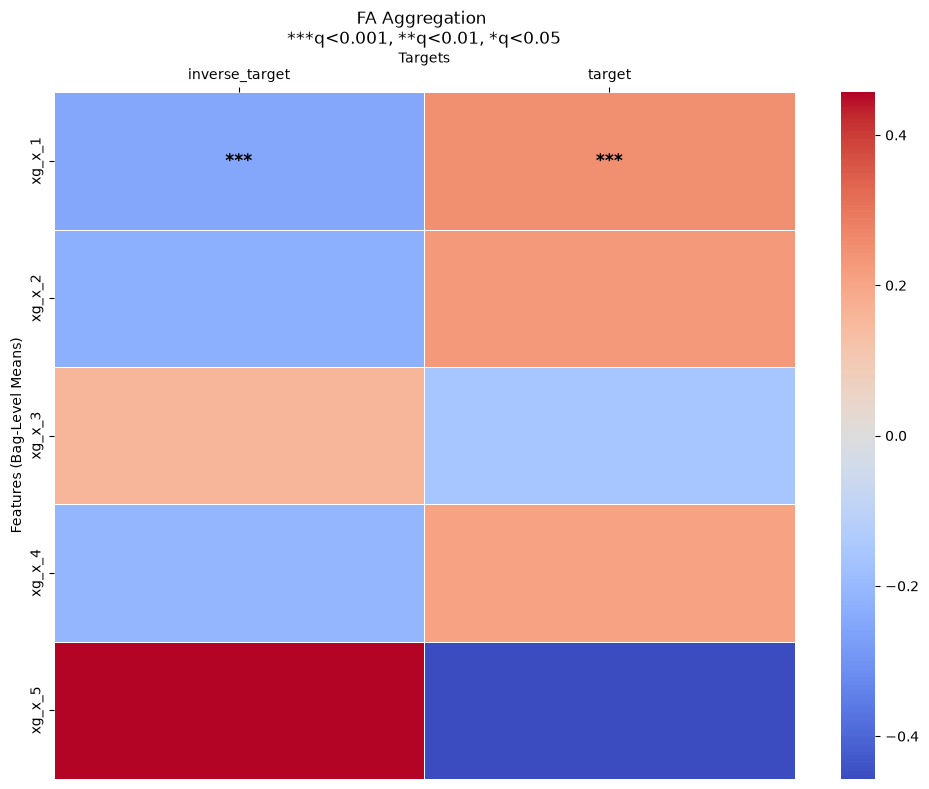

In [40]:
# ---- Plot heatmap of effects----
DCAFA.plot_fa_aggregate_heatmap(agg_results)

## Community Abundance (CA) Analysis

### CA for Instance-level targets


**Goal.**  
Identify communities associated with higher or lower instance-level outcomes.

**Core idea.**  
If we regress each instance’s outcome on its community memberships and the coefficients for some communities are significant, then those communities are predictive of the outcome distribution at the instance level.

**Model (per outcome component $r$).**
$$
t_{p,r} \;\sim\; m_{p1} + \cdots + m_{pK} + v_{s(p)} + (1\,|\,s(p)),
$$

with link $g_r(\cdot)$:
$$
g_r\!\big(\mathbb{E}[t_{p,r}]\big)
\;=\;
\alpha_r
\;+\;
\sum_{k=1}^{K}\gamma_{k,r}\,m_{pk}
\;+\;
v_{s(p)}^\top \eta_r
\;+\;
u_{s(p),r}.
$$
This allows modelling different types (continuous (gaussian), binary (binomial), count (poisson)) targets.

**Reporting and interpretation.**  
- Effect size: $\widehat{\gamma}_{k,r}$ = change in mean/odds/rate of $t_{p,r}$ per unit membership in community $k$.  
- Report $\exp(\widehat{\gamma}_{k,r})$ for odds or rate ratios.  
- Hypothesis: $H_0:\gamma_{k,r}=0$.  
- Intuition: sign and magnitude of $\widehat{\gamma}_{k,r}$ indicate whether community $k$ tends to have higher/lower outcomes.  
- Multiple testing: control FDR across $(k,r)$.

**Caveats.**  
- Exclusive memberships: $\{m_{pk}\}$ collinear with intercept → drop a reference community or constrain $\sum_k \gamma_{k,r}=0$.  
- Overlapping memberships: effects interpreted as *per-unit membership*.  
- Within-bag correlation must be modeled (random intercepts or bag-clustered SEs).

**Interpretation** 
- Hard, exclusive clustering (k-means, Louvain/Leiden) - *Do instances in a given cluster differ systematically in their outcomes?* 
- Soft fractional topics (LDA, NMF) - *Do instances with higher membership in a topic tend to have higher/lower outcomes?*  
- Binary multi-label topics (CorEx) - *Does turning a topic on/off at the instance level shift the outcome distribution?*  
- kNN neighborhoods / local communities - *Do outcomes differ when an instance belongs to specific local neighborhoods?*  
- Annotation-based groups (cell types, histological regions) - *Do annotated groups differ in outcomes at the instance level?* 

---


In [11]:
from typing import Dict, Optional, Tuple, Union

# =============================================================================
# 1) SIMULATION: Instance-level CA data with memberships and bag structure
# =============================================================================

def simulate_ca2_instances(
    N: int = 100,                 # number of bags
    K: int = 4,                   # number of communities
    mean_n: int = 200,            # average instances per bag
    exclusive: bool = True,       # if True, exactly one community per instance
    overlapping_prob: float = 0.3,# if not exclusive: Bernoulli prob per community
    soft_memberships: bool = False,# if True: draw soft m_pk in [0,1] for selected communities
    family: str = "binomial",     # "binomial", "gaussian", or "poisson"
    gamma: Optional[np.ndarray] = None,  # true effects per community (K,)
    alpha0: float = 0.0,          # intercept
    tau_bag: float = 0.8,         # SD of random bag intercept on link scale
    covariates: bool = True,      # include a numeric covariate and a categorical site
    seed: int = 7
) -> Tuple[pd.DataFrame, Dict[str, Union[np.ndarray, Dict]]]:
    """
    Simulate instance-level data for CA2:
        t_{p}  ~  sum_k gamma_k * m_{pk} + covariates + (bag random intercept)
    Membership designs:
        - exclusive=True: one-hot assignment to exactly one community
        - exclusive=False: overlapping; each community active with Bernoulli(overlapping_prob)
        - soft_memberships=True: active communities get m_{pk} ~ Beta(3,2); else 0
    Supported families (target types):
        - "binomial": logistic link; t in {0,1}
        - "gaussian": identity link; t real
        - "poisson":  log link;   t integer counts
    Returns a long DataFrame with columns:
        ['bag_id','t','m_1'..'m_K','x_num','site', ...]
    """
    rng = np.random.default_rng(seed)

    # True community effects γ_k (used in simulation)
    if gamma is None:
        # example: k=1 increases risk, k=3 decreases
        gamma = np.array([1.0, 0.0, -0.8, 0.0], dtype=float)
        if K != 4:
            # scale to K if user chooses a different K
            gamma = np.zeros(K, dtype=float)
            if K >= 1: gamma[0] = 1.0
            if K >= 3: gamma[2] = -0.8
    else:
        gamma = np.asarray(gamma, dtype=float)
        assert gamma.shape == (K,)

    # Simulate bag sizes and bag random intercepts (on link scale)
    n_per_bag = rng.poisson(mean_n, size=N).clip(min=20)
    u_bag = rng.normal(0.0, tau_bag, size=N)  # random effect per bag on link scale

    # Optional bag covariates
    if covariates:
        site = rng.choice(list("ABC"), size=N, p=[0.5, 0.3, 0.2])   # categorical
        age_mean = rng.normal(60, 8, size=N)                         # numeric
    else:
        site = np.array(["A"] * N)
        age_mean = np.zeros(N)

    # Build instances
    rows = []
    for i in range(N):
        n_i = n_per_bag[i]
        # draw per-instance numeric covariate around bag mean (optional)
        x_num_i = rng.normal(loc=age_mean[i], scale=5.0, size=n_i) if covariates else np.zeros(n_i)

        # Create membership matrix m_{pk} for instances in bag i
        M = np.zeros((n_i, K), dtype=float)
        if exclusive:
            # exactly one community: draw a categorical assignment per instance
            # (dirichlet prior can be used to skew; here uniform)
            choices = rng.integers(0, K, size=n_i)
            M[np.arange(n_i), choices] = 1.0
            if soft_memberships:
                # soften the 1.0 into Beta draws but normalize to sum=1 (optional stylistic choice)
                for p in range(n_i):
                    m = np.zeros(K)
                    m[choices[p]] = rng.beta(3, 2)
                    m = m / (m.sum() + 1e-12)
                    M[p] = m
        else:
            # overlapping: Bernoulli per community per instance
            active = rng.random((n_i, K)) < max(min(overlapping_prob, 0.95), 0.05)
            if soft_memberships:
                # draw Beta for active entries; keep 0 for inactive
                M = np.where(active, rng.beta(3, 2, size=(n_i, K)), 0.0)
            else:
                M = active.astype(float)
            # ensure at least one membership per instance (optional)
            none_mask = M.sum(axis=1) == 0
            if none_mask.any():
                idx = np.where(none_mask)[0]
                chosen = rng.integers(0, K, size=len(idx))
                M[idx, chosen] = 1.0

        # Linear predictor on link scale
        lp = alpha0 + u_bag[i] + M.dot(gamma)
        if covariates:
            # add small linear effects from covariates (simulation only)
            # numeric: + 0.01 * (x_num - 60); site: B:+0.2, C:-0.2
            site_eff = {"A": 0.0, "B": 0.2, "C": -0.2}[site[i]]
            lp = lp + 0.01 * (x_num_i - 60.0) + site_eff

        # Generate target t based on chosen family
        if family == "binomial":
            p = 1.0 / (1.0 + np.exp(-lp))
            t = rng.binomial(n=1, p=p, size=n_i)
        elif family == "gaussian":
            t = lp + rng.normal(0.0, 1.0, size=n_i)
        elif family == "poisson":
            mu = np.exp(lp)
            t = rng.poisson(mu, size=n_i)
        else:
            raise ValueError("family must be one of {'binomial','gaussian','poisson'}")

        # Append rows
        for p_idx in range(n_i):
            row = {
                "bag_id": i,
                "target": t[p_idx],
                **{f"m_{k+1}": float(M[p_idx, k]) for k in range(K)},
            }
            if covariates:
                row["x_num"] = float(x_num_i[p_idx])
                row["site"] = site[i]
            rows.append(row)

    df = pd.DataFrame(rows)

    meta = {
        "true_gamma": gamma,
        "alpha0": alpha0,
        "tau_bag": tau_bag,
        "exclusive": exclusive,
        "soft_memberships": soft_memberships,
        "family": family,
        "K": K,
        "N_bags": N
    }
    return df, meta


# ----- Simulate instance-level (binary outcome), exclusive one-hot memberships -----
df, meta = simulate_ca2_instances(
    N=10, K=4, mean_n=150,
    exclusive=True,           # change to False for overlapping memberships
    soft_memberships=False,   # change to True for soft m_{pk} in [0,1]
    family="binomial",        # try "gaussian" or "poisson" as well
    tau_bag=0.7,              # random bag intercept SD
    covariates=True,          # include x_num and site
    seed=123
)

# Inspect schema
print("Columns:", df.columns.tolist()[:10], "...")
print("Example rows:\n", df.head(), "\n")
print("True community effects (gamma):", meta["true_gamma"])


Columns: ['bag_id', 'target', 'm_1', 'm_2', 'm_3', 'm_4', 'x_num', 'site'] ...
Example rows:
    bag_id  target  m_1  m_2  m_3  m_4      x_num site
0       0       1  0.0  1.0  0.0  0.0  71.580869    A
1       0       0  0.0  0.0  1.0  0.0  71.716238    A
2       0       0  0.0  0.0  1.0  0.0  69.031694    A
3       0       1  0.0  0.0  1.0  0.0  68.522471    A
4       0       1  0.0  0.0  1.0  0.0  67.128706    A 

True community effects (gamma): [ 1.   0.  -0.8  0. ]


In [12]:
# ----- Fit GLM with memberships + covariates (drop reference to avoid collinearity when exclusive) -----
membership_cols = [c for c in df.columns if c.startswith("m_")]
effects = DCAFA.fit_ca_inst(
    df=df,
    target_col="target",
    membership_cols=membership_cols,
    covariates=[],#["x_num", "site"],   # you can pass [] to exclude covariates
    bag_id_col="bag_id",
    family="binomial",               # "gaussian" or "poisson"
    drop_reference_if_exclusive=True,
    cov_type="cluster"
)

# Tidy results
print("\nCA2 effects (memberships first):")
print(effects.head(12))


CA2 effects (memberships first):
  term  is_membership      coef        se             p     ci_lo     ci_hi  \
0  m_1           True  1.212013  0.111493  1.588351e-27  0.993491  1.430535   
1  m_2           True  0.039029  0.123266  7.515296e-01 -0.202568  0.280625   
2  m_3           True -0.680279  0.118244  8.757504e-09 -0.912032 -0.448525   

   effect_plot  effect_lo  effect_hi  nobs             q significant  \
0     3.360242   2.700647   4.180935  1551  4.765052e-27        True   
1     1.039800   0.816631   1.323958  1551  7.515296e-01       False   
2     0.506476   0.401707   0.638569  1551  1.313626e-08        True   

      deviance  pearson_chi2  
0  1941.167431        1551.0  
1  1941.167431        1551.0  
2  1941.167431        1551.0  


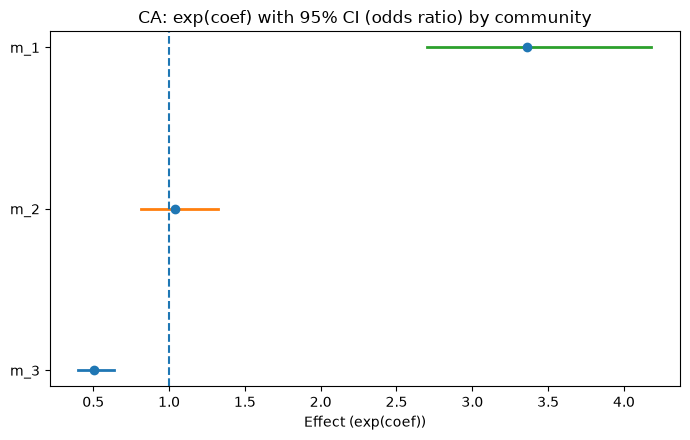

In [13]:
# ----- Forest plot (memberships only) -----
DCAFA.plot_ca_inst_forest(
    effects_df=effects,
    family="binomial",
    title="CA: exp(coef) with 95% CI (odds ratio) by community"
)

### CA for Bag Level Targets


**Goal.**  
Test whether the *relative abundance* of a community is associated with bag-level outcomes.

**Core idea.**  
If we regress the (relative) counts of instances of each bag in each community on the bag-level outcome, and the regression coefficients are significant, then community-level abundance helps explain variation in bag-level targets.

**Model (per community $k$).**
$$
c_{ik} \;\sim\; y_i + v_i + \text{offset}(\log n_i),
\qquad c_{ik}\sim \mathrm{NB}(\mu_{ik}, \alpha_k)
$$

with  
$$
\log \mu_{ik} \;=\; \beta_{0k} \;+\; y_i^\top \beta_k \;+\; v_i^\top \delta_k \;+\; \log n_i.
$$

**Reporting and interpretation.**  
- Effect size: $\widehat{\beta}_{k,m}$ = log fold-change in expected *proportion* of community $k$ per unit increase in outcome $y_{i,m}$.  
- Report $\exp(\widehat{\beta}_{k,m})$ as multiplicative change.  
- Hypothesis: $H_0:\beta_{k,m}=0$.  
- Significance: Wald or likelihood ratio test, adjusted to $q_{k,m}$ (BH-FDR).  
- Intuition: if $q_{k,m}<0.05$, community $k$ is enriched ($\widehat{\beta}_{k,m}>0$) or depleted ($<0$) as outcome $m$ increases.

**Caveats.**  
- Exclusive memberships: $c_{ik}$ are compositional (sum to $n_i$). Interpretation is relative.  
- Overdispersion handled by $\alpha_k$.  
- Covariates $v_i$ (e.g., site/batch) must be included to avoid confounding.

**Interpretation** 
- Hard, exclusive clustering (k-means, Louvain/Leiden) - *Do bags with different outcomes show enrichment or depletion of certain clusters?*  
- Soft fractional topics (LDA, NMF) - *Do the proportions of topic usage differ across bags with different outcomes?*  
- Binary multi-label topics (CorEx) - *Are bags with higher counts of topic-on instances enriched for certain outcomes?*  
- kNN neighborhoods / local communities - *Are certain local neighborhoods enriched in particular outcomes at the bag level?* 
- Annotation-based groups (cell types, histological regions) -  *Are certain annotated groups more/less abundant in bags with given outcomes?*

---

In [14]:
# -------------------------------------------------------------------------
# EXAMPLE: how to frame the DataFrame and call the function
# -------------------------------------------------------------------------

# --- Example toy data generation (re-using previous simulator) ---
# Here we create one binary target y_resp and add two covariates: age (numeric), site (categorical)
from numpy.random import default_rng
rng = default_rng(7)

# Simulate a small dataset
N, K = 250, 4
n = rng.poisson(1000, size=N).clip(min=100)
y_resp = rng.integers(0, 2, size=N)                # target 1 (binary)
y_score = rng.normal(0, 1, size=N)                 # target 2 (continuous)
age = rng.normal(60, 10, size=N)                   # numeric covariate
site = rng.choice(list("ABC"), size=N, p=[0.5, 0.3, 0.2])  # categorical covariate

# True effects for demo (only for generating c_k)
beta0 = np.array([-2.0, -2.2, -2.1, -2.3])
betas_resp = np.array([0.5, 0.0, -0.4, 0.0])       # effect of y_resp on c_k
betas_score = np.array([0.2, 0.0, -0.15, 0.0])     # effect per 1 SD of y_score
alpha = np.array([0.6, 0.7, 0.6, 0.7])             # dispersions

# Build counts as NB around log(mu) = beta0_k + (0.8*y_resp + 0.4*y_score)*beta_k + log(n)
# (Just a toy way to make both targets relevant; the *analysis* still fits one target at a time.)
C = np.zeros((N, K), dtype=int)
for k in range(K):
    eta = beta0[k] + (0.8*y_resp) * betas_resp[k] + (0.4*y_score) * betas_score[k] + np.log(n)
    mu = np.exp(eta)
    shape = 1.0 / alpha[k]
    scale = alpha[k] * mu
    lam = rng.gamma(shape, scale)
    C[:, k] = rng.poisson(lam)

df = pd.DataFrame({
    "n": n,
    "c_1": C[:, 0], "c_2": C[:, 1], "c_3": C[:, 2], "c_4": C[:, 3],
    "y_resp": y_resp,
    "y_score": y_score,
    "age": age,
    "site": site
})

print(df.head())

      n  c_1  c_2  c_3  c_4  y_resp   y_score        age site
0  1011  291   26  421   19       0 -0.829150  60.684106    C
1  1027  124   99   55   37       0 -1.646231  70.362958    A
2   981   30   60  329   89       0 -1.436730  55.428933    A
3  1030  334  140  295    3       0  0.665429  52.934659    A
4   981  140    4  318   99       0 -0.758377  58.114501    B


In [15]:
# --- Run multi-target CA1 ---
results = DCAFA.fit_ca_bag(
    df=df,
    K=K,
    target_cols=["y_resp", "y_score"],   # multiple targets
    covariates=["age", "site"],          # add any bag covariates
    offset_col="n",
    cov_type="HC1",
    outdir=None,                # will save CSVs and PNGs here
    plot=False
)

results["y_resp"]

,target,community,response,term,coef_log,se,p,ci_lo,ci_hi,exp_coef,exp_ci_lo,exp_ci_hi,deviance,pearson_chi2,nobs,q,significant
0,y_resp,k=1,c_1,site[T.B],-0.031440,0.121817,0.796334,-0.270198,0.207317,0.969049,0.763229,1.230372,177.664550,164.307816,250,0.939216,False
1,y_resp,k=1,c_1,site[T.C],0.060533,0.128315,0.637104,-0.190959,0.312024,1.062402,0.826166,1.366188,177.664550,164.307816,250,0.650781,False
2,y_resp,k=1,c_1,y_resp,0.258966,0.103211,0.012104,0.056676,0.461256,1.295590,1.058313,1.586064,177.664550,164.307816,250,0.024208,True
3,y_resp,k=1,c_1,age,0.000467,0.004961,0.925019,-0.009257,0.010191,1.000467,0.990786,1.010243,177.664550,164.307816,250,0.925019,False
4,y_resp,k=2,c_2,site[T.B],-0.034899,0.128171,0.785402,-0.286109,0.216311,0.965703,0.751180,1.241489,188.182559,185.216658,250,0.939216,False
5,y_resp,k=2,c_2,site[T.C],0.123121,0.133554,0.356589,-0.138639,0.384881,1.131021,0.870542,1.469439,188.182559,185.216658,250,0.650781,False
6,y_resp,k=2,c_2,y_resp,0.004607,0.110354,0.966701,-0.211683,0.220897,1.004617,0.809221,1.247194,188.182559,185.216658,250,0.966701,False
7,y_resp,k=2,c_2,age,0.013380,0.004976,0.007167,0.003628,0.023133,1.013470,1.003634,1.023403,188.182559,185.216658,250,0.028669,True
8,y_resp,k=3,c_3,site[T.B],-0.009103,0.119379,0.939216,-0.243082,0.224876,0.990938,0.784207,1.252167,164.011484,148.289128,250,0.939216,False
9,y_resp,k=3,c_3,site[T.C],0.057240,0.126448,0.650781,-0.190593,0.305073,1.058910,0.826469,1.356724,164.011484,148.289128,250,0.650781,False


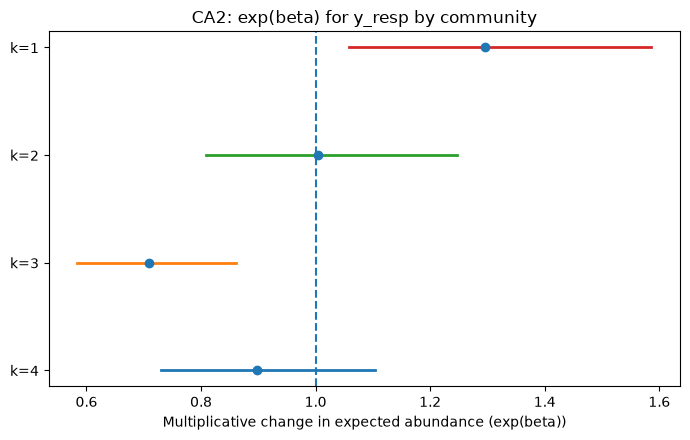

In [16]:
# ----- CA Forest plot -----
DCAFA.plot_ca_bag_forest(
    effects=results["y_resp"],
    term="y_resp",
    title=f"CA2: exp(beta) for y_resp by community",
    x_label="Multiplicative change in expected abundance (exp(beta))",
    outpath=None
)

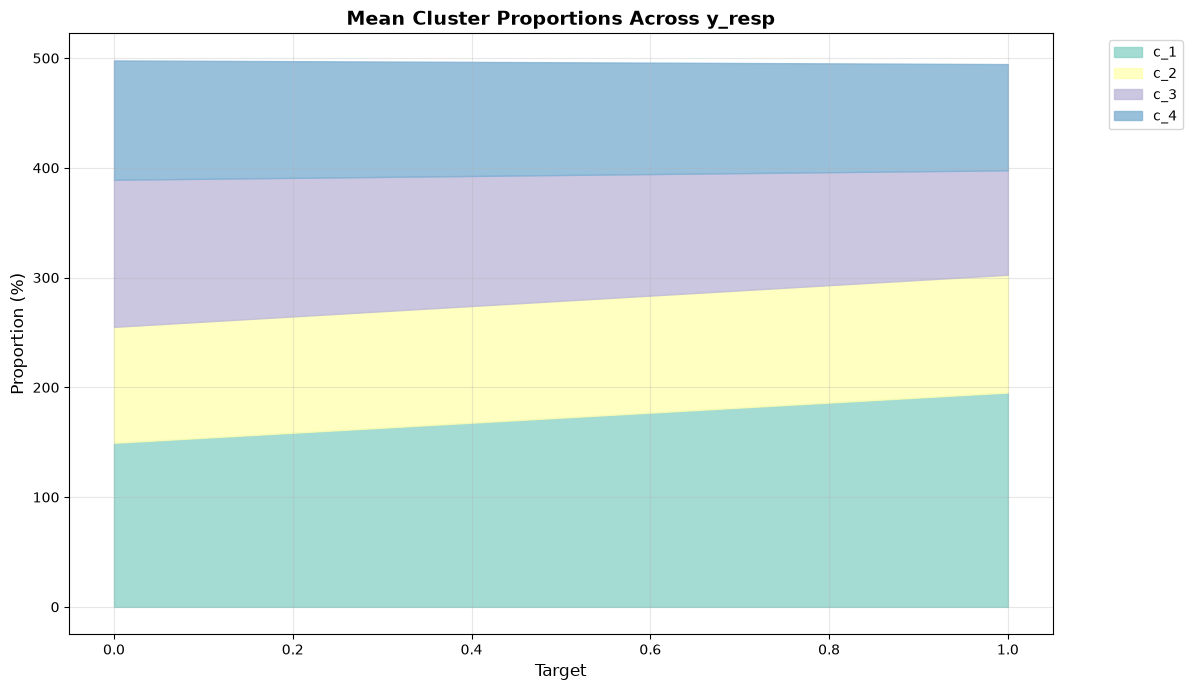

In [18]:
# ----- CA stacked area plot -----
DCAFA.ca_stacked_area_plot(df, target_col = "y_resp", cluster_cols=['c_1','c_2','c_3','c_4'])